##### Time series prediction using XGBoost for solar data (2011 - 2015)

* Training - 2011 to 2014
* Testing - 2015

In [ ]:
!pip install xgboost statsmodels

In [ ]:
!pip install prophet openpyxl

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
from datetime import datetime
from prophet import Prophet

color_pal = sns.color_palette()

In [2]:
# Override the default linewidth and markersize
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 5

In [3]:
# Import dataset
df = pd.read_csv('2011_2015_solar.csv')
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])

df = df.drop(['Year', 'Month', 'Day', 'Hour'], axis = 1)
df_hourly = df[['Date', 'GHI']].set_index('Date')

In [4]:
df_hourly.head()

,GHI
Date,
2011-01-01 00:00:00,0
2011-01-01 01:00:00,0
2011-01-01 02:00:00,0
2011-01-01 03:00:00,0
2011-01-01 04:00:00,0


In [5]:
# Define target test cutoff date

TARGET_TEST_CUTOFF_DATE = '2014-12-31 23:00:00'

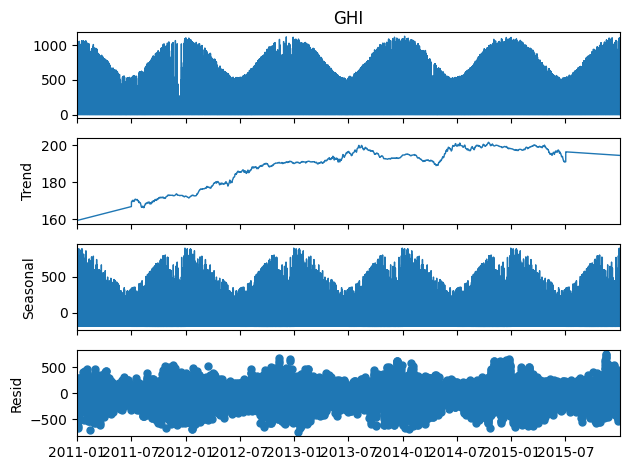

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

ANNUAL_PERIOD = 365*24
mult_decomp = seasonal_decompose(df_hourly['GHI'], model = 'additive', extrapolate_trend = 'freq', period = ANNUAL_PERIOD)
mult_decomp.plot()
plt.show()

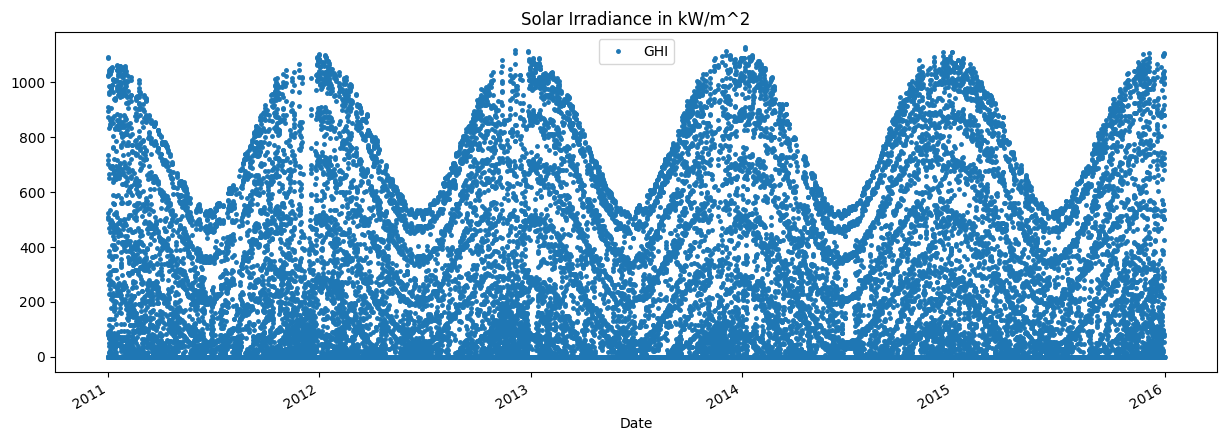

In [7]:
df_hourly.plot(style = '.',
               figsize = (15, 5),
               color = color_pal[0],
               title = 'Solar Irradiance in kW/m^2')

plt.show()

In [8]:
df_hourly = df_hourly.loc[df_hourly.GHI != 0] # Ignore the hours when production is zero.

In [9]:
train = df_hourly.loc[df_hourly.index <= TARGET_TEST_CUTOFF_DATE]
test = df_hourly.loc[df_hourly.index > TARGET_TEST_CUTOFF_DATE]

In [10]:
train.head()

,GHI
Date,
2011-01-01 05:00:00,91
2011-01-01 06:00:00,299
2011-01-01 07:00:00,524
2011-01-01 08:00:00,735
2011-01-01 09:00:00,910


In [11]:
# Function for plotting train-test splits

def plot_train_test_split(df: pd.DataFrame, split_date: str) -> None:
  """
  Plots the train/test split of the input DataFrame.

  Args:
    df (pd.DataFrame): Input DataFrame with a DatetimeIndex
    split_date(str): Date in the format 'YYYY-MM-DD H:M:S' to split the DataFrame.

  Returns:
    None
  """

  train = df.loc[df.index <= split_date]
  test = df.loc[df.index > split_date]

  fig, ax = plt.subplots(figsize = (15, 5))
  train.plot(ax = ax, label = 'Training Set', title = 'Data Train/Test Split', linewidth = 1, markersize = 5)
  test.plot(ax = ax, label = 'Test Set', linewidth = 1, markersize = 5)
  ax.axvline(pd.Timestamp(split_date), color = 'black', ls = '--')
  ax.legend(['Training Set', 'Test Set'])
  plt.show()

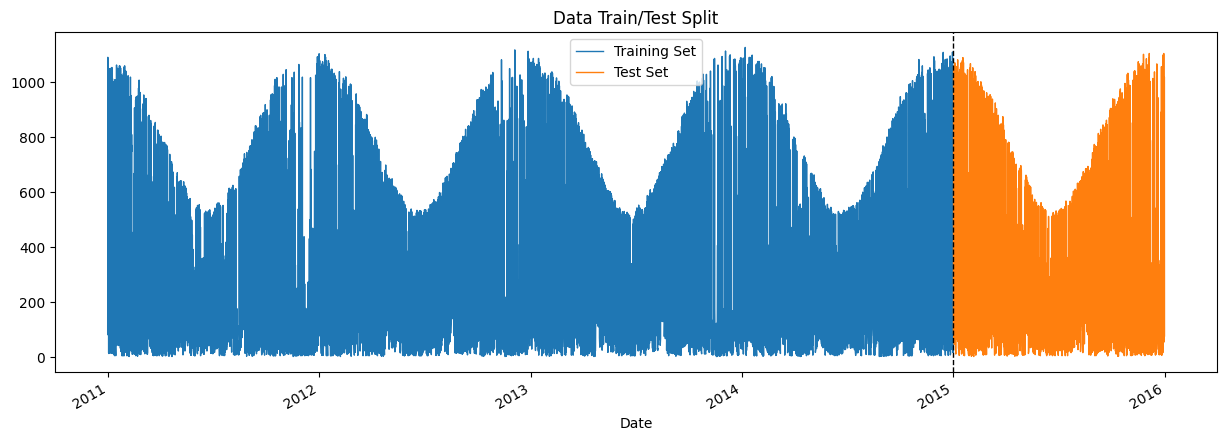

In [12]:
plot_train_test_split(df_hourly, TARGET_TEST_CUTOFF_DATE)

In [13]:
# Function for plotting between two date ranges. To see how a single weekly data looks like

def plot_week_of_data(df: pd.DataFrame, start_date: str, end_date: str) -> None:
  """
  Plot a week of data from the input DataFrame within a specified date range.

  Args:
    df (pd.DataFrame): Input DataFrame with a DatetimeIndex
    start_date(str): Start date in the format 'YYYY-MM-DD H:M:S'
    end_date(str): End date in the format 'YYYY-MM-DD H:M:S'

  Returns:
    None
  """
  df.loc[(df.index > start_date) & (df.index < end_date)].plot(figsize = (15, 5), \
                                    title = 'Week of Data', linewidth = 1, markersize = 5)

  plt.show()

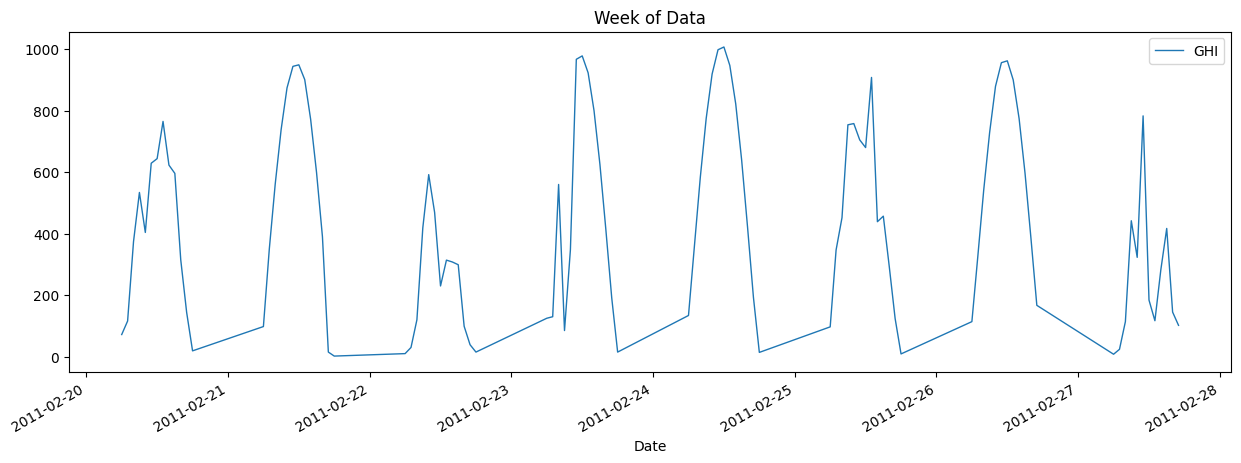

In [14]:
plot_week_of_data(df_hourly, '2011-02-20 00:00:00', '2011-02-27 23:00:00')

In [15]:
# Feature Engineeering for Time Series

def create_time_series_features(df: pd.DataFrame) -> pd.DataFrame:
  """
  From Date column of the original dataframe create features for the time series

  Args:
    df (pd.DataFrame): Input DataFrame with a Datetime Index

  Returns:
    pd.DataFrame: DataFrame with additional time series features

  Raises:
    ValueError: If input DataFrame does not have a Datetime Index.
  """

  if not isinstance(df.index, pd.DatetimeIndex):
    raise ValueError("Input DataFrame must have a Datetime Index.")

  df = df.copy()

  features = {
      'hour': df.index.hour,
      'dayofweek': df.index.dayofweek,
      'quarter': df.index.quarter,
      'month': df.index.month,
      'year': df.index.year,
      'dayofyear': df.index.dayofyear,
      'dayofmonth': df.index.day,
      'weekofyear': df.index.isocalendar().week
      # 'GHI_lag1': df['GHI'].shift(1),
      # 'GHI_lag2': df['GHI'].shift(2),
      # 'GHI_lag3': df['GHI'].shift(3),
      # 'GHI_lag4': df['GHI'].shift(4),
      # 'GHI_lag5': df['GHI'].shift(5),
      # 'GHI_lag6': df['GHI'].shift(6),
      # 'GHI_lag7': df['GHI'].shift(7)
  }

  for feature_name, feature_values in features.items():
    df[feature_name] = feature_values

  return df

In [16]:
hourly_df = create_time_series_features(df_hourly)
hourly_df = hourly_df.dropna()
hourly_df.tail(10)

,GHI,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,
2015-12-31 09:00:00,881,9,3,4,12,2015,365,31,53
2015-12-31 10:00:00,945,10,3,4,12,2015,365,31,53
2015-12-31 11:00:00,997,11,3,4,12,2015,365,31,53
2015-12-31 12:00:00,1018,12,3,4,12,2015,365,31,53
2015-12-31 13:00:00,1014,13,3,4,12,2015,365,31,53
2015-12-31 14:00:00,841,14,3,4,12,2015,365,31,53
2015-12-31 15:00:00,679,15,3,4,12,2015,365,31,53
2015-12-31 16:00:00,500,16,3,4,12,2015,365,31,53
2015-12-31 17:00:00,277,17,3,4,12,2015,365,31,53


##### Creating our Model

In [18]:
train.head()

,GHI
Date,
2011-01-01 05:00:00,91
2011-01-01 06:00:00,299
2011-01-01 07:00:00,524
2011-01-01 08:00:00,735
2011-01-01 09:00:00,910


In [19]:
test.head()

,GHI
Date,
2015-01-01 05:00:00,87
2015-01-01 06:00:00,291
2015-01-01 07:00:00,514
2015-01-01 08:00:00,724
2015-01-01 09:00:00,899


In [20]:
train = create_time_series_features(train).dropna()
test = create_time_series_features(test).dropna()

In [21]:
train.head()

,GHI,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,
2011-01-01 05:00:00,91,5,5,1,1,2011,1,1,52
2011-01-01 06:00:00,299,6,5,1,1,2011,1,1,52
2011-01-01 07:00:00,524,7,5,1,1,2011,1,1,52
2011-01-01 08:00:00,735,8,5,1,1,2011,1,1,52
2011-01-01 09:00:00,910,9,5,1,1,2011,1,1,52


In [22]:
train['weekofyear'] = train['weekofyear'].astype('int32')
test['weekofyear'] = test['weekofyear'].astype('int32')

In [23]:
# Defining the train and test features & target for the TS

time_series_features = ['hour', 'dayofmonth', 'month']

time_series_target = 'GHI'

X_train = train[time_series_features]
y_train = train[time_series_target]

X_test = test[time_series_features]
y_test = test[time_series_target]

In [24]:
# XGBoost regressor function code

def train_xgb_regressor(X_train, y_train, X_test, y_test, use_gpu = False):
  """
  Train an XGBoost Regressor model using the provided training and test data

  Args:
    X_train: Training feature set.
    y_train: Training target set.
    X_test: Test feature set.
    y_test: Test target set.
    use_gpu (bool): Whether to use GPU for training. Default is False.

  Returns:
    xgb.XGBRegressor: Trained XGBoost Regressor model.
  """

  additional_params = {}
  if use_gpu:
    additional_params = {'tree_method': 'gpu_hist', 'gpu_id': 0}

  xgb_regressor = xgb.XGBRegressor(base_score = 0.5, booster = 'gbtree',
                                   n_estimators = 3000,
                                   early_stopping_rounds = 50,
                                   objective = 'reg:linear',
                                   max_depth = 6,
                                   learning_rate = 0.01,
                                   min_child_weight = 1,
                                   subsample = 0.8,
                                   colsample_bytree = 0.8,
                                   gamma = 0,
                                   reg_alpha = 0,
                                   reg_lambda = 1,
                                   **additional_params)
  xgb_regressor.fit(X_train, y_train,
                    eval_set = [(X_train, y_train), (X_test, y_test)],
                    verbose = 100)

  return xgb_regressor

In [25]:
model = train_xgb_regressor(X_train, y_train, X_test, y_test, use_gpu = False)

[0]	validation_0-rmse:478.35001	validation_1-rmse:486.69937


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [22:24:13] WARNING: /workspace/src/objective/regression_obj.cu:209: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:265.95256	validation_1-rmse:274.97303
[200]	validation_0-rmse:206.74452	validation_1-rmse:216.08245
[300]	validation_0-rmse:191.41358	validation_1-rmse:201.50428
[400]	validation_0-rmse:186.27943	validation_1-rmse:197.33063
[500]	validation_0-rmse:184.10449	validation_1-rmse:196.10635
[600]	validation_0-rmse:182.81023	validation_1-rmse:195.80192
[638]	validation_0-rmse:182.48284	validation_1-rmse:195.80259


##### Do a feature importance plot

In [26]:
# Plot feature importance

def plot_feature_importance(model):
  """
  Plot the feature importance of a trained XGBoost model

  Args:
    model (xgb.XGBRegressor): Trained XGBoost Regressor model.

  Returns:
    None
  """
  feat_importances = pd.DataFrame(data = model.feature_importances_,
                                  index = model.feature_names_in_,
                                  columns = ['importance'])
  feat_importances.sort_values('importance').plot(kind = 'barh', title = 'Feature Importance (Solar Irradiance)')

  plt.show()

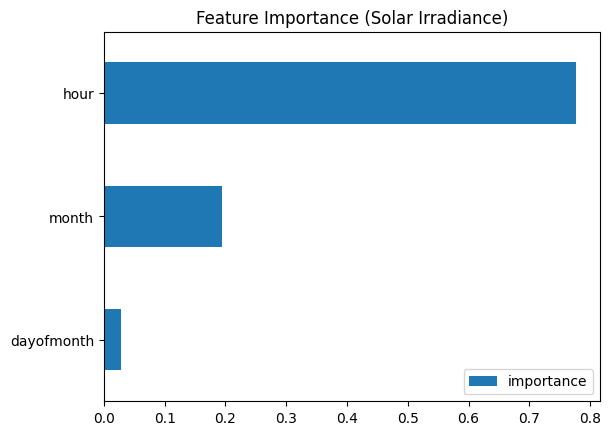

In [27]:
plot_feature_importance(model)

##### Inference on Test

In [28]:
test['prediction'] = model.predict(X_test)

hourly_df = hourly_df.merge(test[['prediction']], how = 'left', left_index = True, \
                            right_index = True)

In [29]:
hourly_df.tail()

,GHI,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction
Date,,,,,,,,,,
2015-12-31 14:00:00,841,14,3,4,12,2015,365,31,53,720.989258
2015-12-31 15:00:00,679,15,3,4,12,2015,365,31,53,588.223999
2015-12-31 16:00:00,500,16,3,4,12,2015,365,31,53,432.610077
2015-12-31 17:00:00,277,17,3,4,12,2015,365,31,53,288.769043
2015-12-31 18:00:00,76,18,3,4,12,2015,365,31,53,159.608231


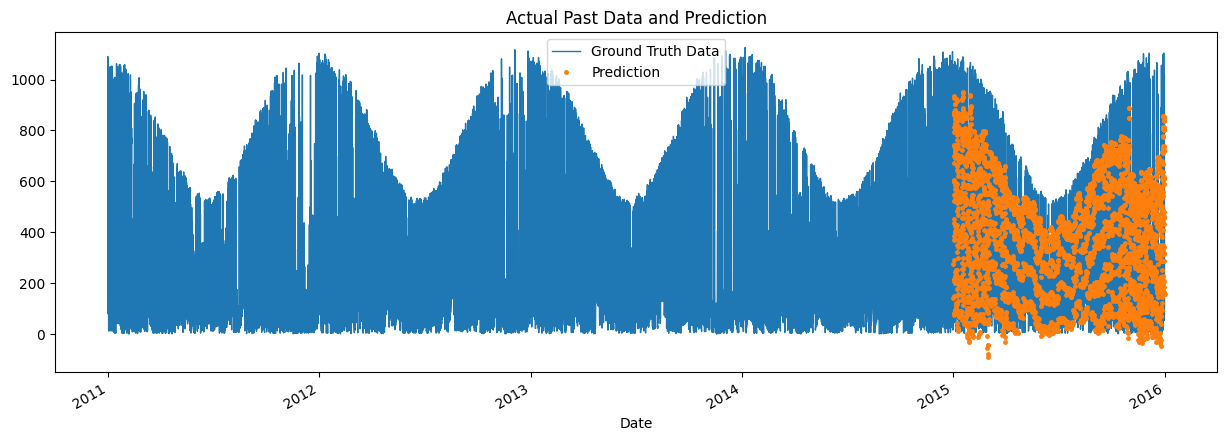

In [30]:
# Visualizing prediction against ground truth data

ax = hourly_df[['GHI']].plot(figsize = (15, 5))

hourly_df['prediction'].plot(ax = ax, style = '.')

plt.legend(['Ground Truth Data', 'Prediction'])
ax.set_title('Actual Past Data and Prediction')

plt.show()

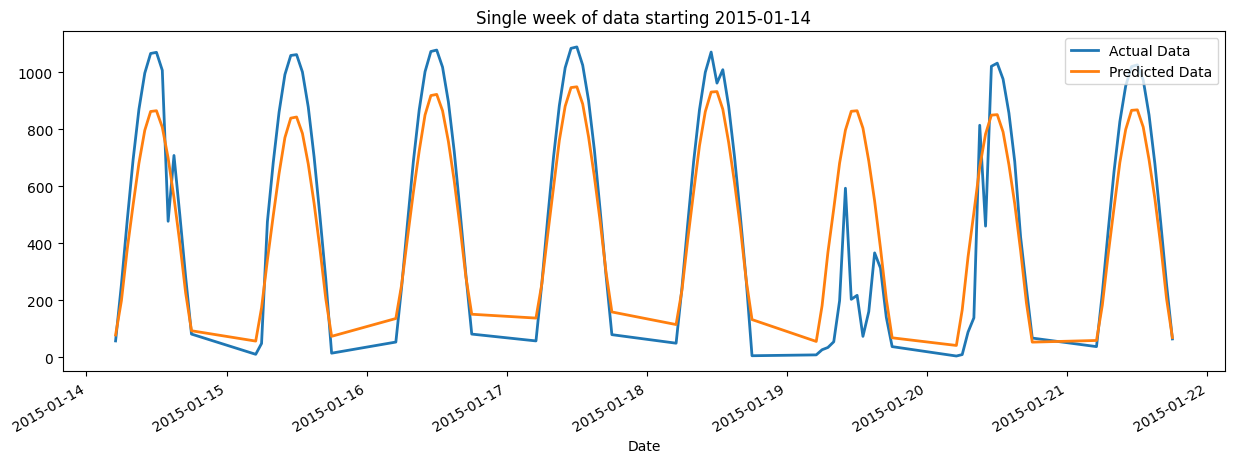

In [31]:
# Select Data within a certain date range

data = hourly_df.loc['2015-01-14':'2015-01-21']

# Plot the actual and predicted data
ax = data['GHI'].plot(figsize = (15, 5), title = 'Single week of data starting 2015-01-14', linewidth = 2, markersize = 5)

data['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

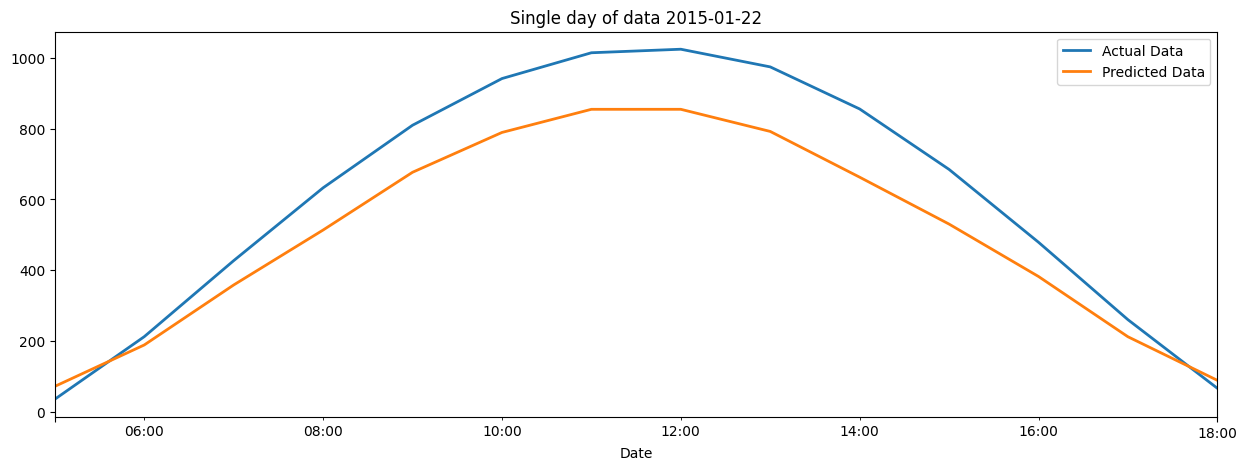

In [32]:
# Select data for all hours in a single day
data_one_day = hourly_df.loc['2015-01-22':'2015-01-22']

# Plot the actual and predicted data
ax = data_one_day['GHI'].plot(figsize = (15, 5), title = 'Single day of data 2015-01-22', linewidth = 2, markersize = 5)

data_one_day['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

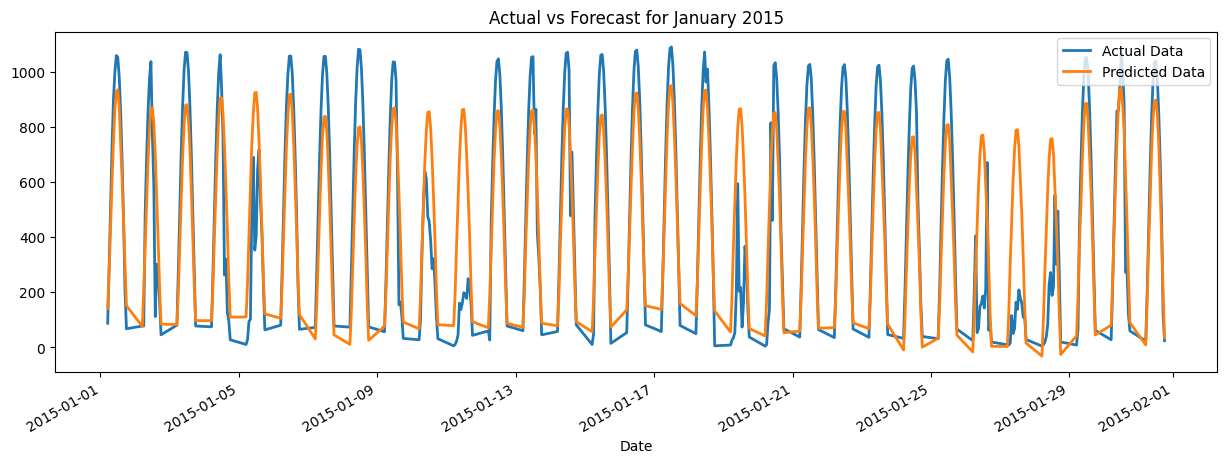

In [33]:
# For the whole of January

# Select data for the month of January

data_month = hourly_df.loc['2015-01-01':'2015-01-31']

# Plot the actual and predicted data
ax = data_month['GHI'].plot(figsize = (15, 5), title = 'Actual vs Forecast for January 2015', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

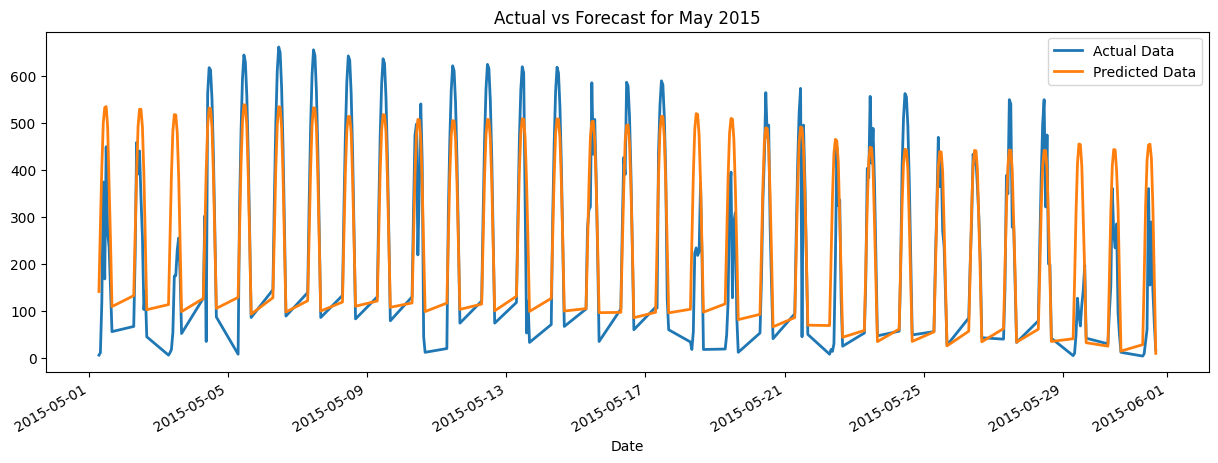

In [34]:
# For the whole of May

# Select data for the month of May

data_month = hourly_df.loc['2015-05-01':'2015-05-31']

# Plot the actual and predicted data
ax = data_month['GHI'].plot(figsize = (15, 5), title = 'Actual vs Forecast for May 2015', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

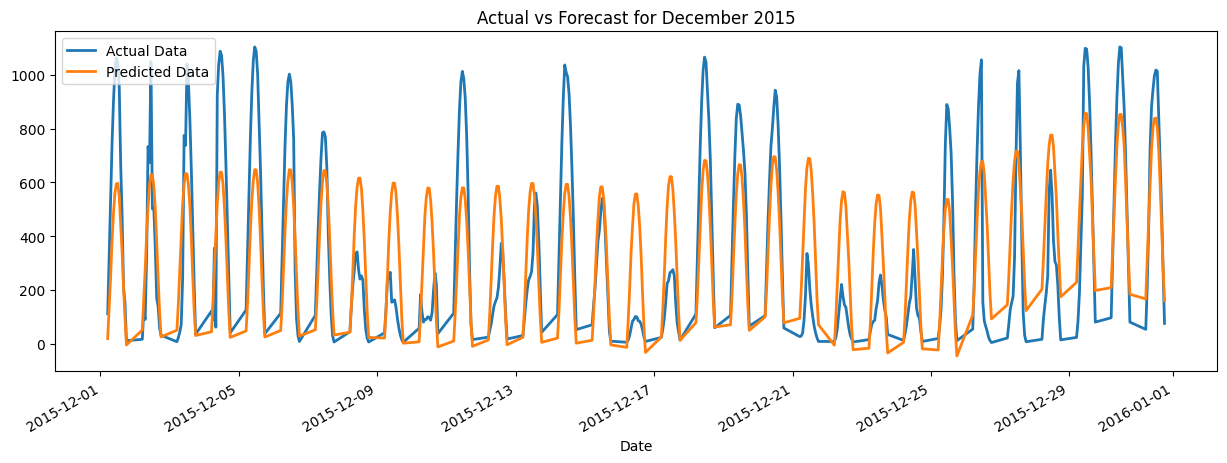

In [35]:
# For the whole of December

# Select data for the month of December

data_month = hourly_df.loc['2015-12-01':'2015-12-31']

# Plot the actual and predicted data
ax = data_month['GHI'].plot(figsize = (15, 5), title = 'Actual vs Forecast for December 2015', linewidth = 2, markersize = 5)

data_month['prediction'].plot(style = '-', linewidth = 2, markersize = 5)

plt.legend(['Actual Data', 'Predicted Data'])

plt.show()

##### RMSE

In [36]:
score = np.sqrt(mean_squared_error(test['GHI'], test['prediction']))

print(f'RMSE Score on Test set: {score: 0.2f}')

RMSE Score on Test set:  195.78


In [37]:
# Compute the error of each forecast

test['error_solar'] = np.abs(test['GHI'] - test['prediction'])

In [40]:
# Save the error in load demand (MW) for predicted year 2013

pred_2015_data = test[['error_solar']]

import pickle

with open('error_solar_2015.pickle', 'wb') as file:
  pickle.dump(pred_2015_data, file)